In [32]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A
import shutil

In [33]:
dataset_path = "../data"

image_paths = []
labels = []

classes = os.listdir(dataset_path)

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    subfolders = os.listdir(class_path)
    img_folder = os.path.join(class_path, subfolders[0])

    for img_name in os.listdir(img_folder):
        img_path = os.path.join(img_folder, img_name)
        image_paths.append(img_path)
        labels.append(cls)

print("Total images:", len(image_paths))
print("Classes:", classes)

Total images: 2688
Classes: ['Blowhole', 'Break', 'Crack', 'Fray', 'Free', 'Uneven']


In [34]:
clean_paths = []
clean_labels = []

for path, label in zip(image_paths, labels):
    try:
        img = cv2.imread(path)

        if img is None:
            continue

        clean_paths.append(path)
        clean_labels.append(label)

    except:
        continue

print("Clean images:", len(clean_paths))

Clean images: 2688


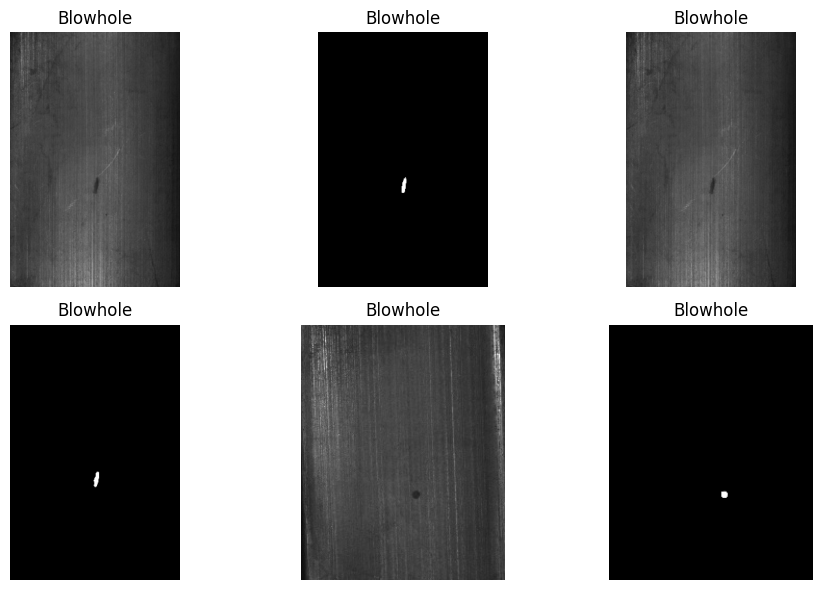

In [35]:
plt.figure(figsize=(10,6))

for i in range(6):
    img = cv2.imread(clean_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(clean_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 640

def resize_image(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

def normalize_image(img):
    return img.astype(np.float32) / 255.0

def denoise_image(img):
    return cv2.GaussianBlur(img, (5,5), 0)

In [40]:
output_dir = "../processed_data"
os.makedirs(output_dir, exist_ok=True)

for path in clean_paths:
    img = cv2.imread(path)

    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = resize_image(img)
    img = denoise_image(img)

    # convert back for saving
    img = img.astype(np.uint8)

    save_path = os.path.join(output_dir, os.path.basename(path))
    cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

In [41]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.5)
])

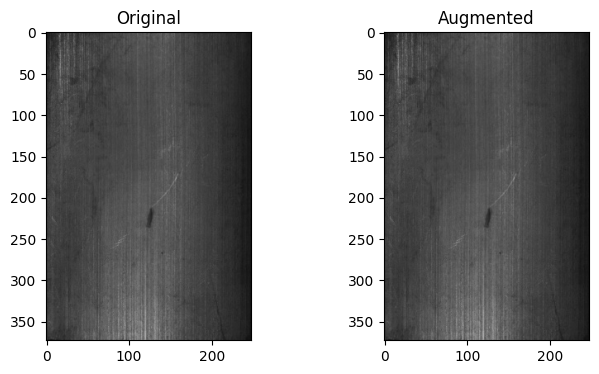

In [42]:
sample = cv2.imread(clean_paths[0])
sample = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)

aug = transform(image=sample)
aug_img = aug["image"]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(aug_img)
plt.title("Augmented")

plt.show()

In [43]:
X_train, X_temp, y_train, y_temp = train_test_split(
    clean_paths,
    clean_labels,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 1881
Val: 403
Test: 404


In [44]:
base_dir = "../dataset_yolo"

os.makedirs(base_dir + "/images/train", exist_ok=True)
os.makedirs(base_dir + "/images/val", exist_ok=True)
os.makedirs(base_dir + "/images/test", exist_ok=True)

os.makedirs(base_dir + "/labels/train", exist_ok=True)
os.makedirs(base_dir + "/labels/val", exist_ok=True)
os.makedirs(base_dir + "/labels/test", exist_ok=True)

print("YOLO folder structure created")

YOLO folder structure created


In [45]:
def copy_images(image_list, split):
    for img_path in image_list:
        filename = os.path.basename(img_path)

        dest_path = os.path.join(base_dir, f"images/{split}/{filename}")
        shutil.copy(img_path, dest_path)

copy_images(X_train, "train")
copy_images(X_val, "val")
copy_images(X_test, "test")

print("Images copied successfully")

Images copied successfully
